# Arbres, bagging et boosting pour la classification d'images

## Configuration du notebook

In [1]:
import zipfile
import tempfile
import pathlib
import struct

import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colormaps
from mpl_toolkits.axes_grid1 import make_axes_locatable

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import GridSearchCV
from sklearn.base import BaseEstimator, TransformerMixin

## Extraction des données

In [2]:
def charger_images_mnist(chemin_fichier):
    """Charge un fichier d'images MNIST (.idx3-ubyte) et le prépare pour l'ACP."""
    with open(chemin_fichier, 'rb') as f:
        magic, num_images, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num_images, rows * cols)
    return images

def charger_labels_mnist(chemin_fichier):
    """Charge un fichier d'étiquettes MNIST (.idx1-ubyte)."""
    with open(chemin_fichier, 'rb') as f:
        magic, num_items = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

In [3]:
chemin_donnees = "../../../../Données/mnist.zip"  # A adapter selon vos besoins
tmp = pathlib.Path(tempfile.gettempdir())
chemin_travail = tmp.joinpath("MNIST")

In [4]:
archive = zipfile.ZipFile(chemin_donnees)
archive.extractall(chemin_travail)

In [5]:
images_train = charger_images_mnist(chemin_travail.joinpath("train-images-idx3-ubyte").joinpath("train-images-idx3-ubyte"))
labels_train = charger_labels_mnist(chemin_travail.joinpath("train-labels-idx1-ubyte").joinpath("train-labels-idx1-ubyte"))
images_train.shape, labels_train.shape

((60000, 784), (60000,))

In [6]:
images_test = charger_images_mnist(chemin_travail.joinpath("t10k-images-idx3-ubyte").joinpath("t10k-images-idx3-ubyte"))
labels_test = charger_labels_mnist(chemin_travail.joinpath("t10k-labels-idx1-ubyte").joinpath("t10k-labels-idx1-ubyte"))
images_test.shape, labels_test.shape

((10000, 784), (10000,))

Normalisation des images:

In [7]:
images_train = images_train / 255.
images_test = images_test / 255.

## Fonctions de visualisation

In [8]:
def visualiser_image(images, labels, index = None, label = None):
    if index is None:
        index = np.random.choice(images.shape[0])
    image = images[index]
    p = image.shape[0]
    image = image.reshape(int(np.sqrt(p)), int(np.sqrt(p)))
    if label is None:
        label = f"{labels[index]}"
    else:
        label = f"{label}: {labels[index]}"
    plt.imshow(image, cmap="gray", vmin=0., vmax=1.)
    plt.axis("off")
    plt.title(label)

In [9]:
def visualiser_image_classification(images, labels, scores, index=None, label=None):
    if index is None:
        index = np.random.choice(images.shape[0])
    image = images[index]
    p = image.shape[0]
    image = image.reshape(int(np.sqrt(p)), int(np.sqrt(p)))
    if label is None:
        label = f"{labels[index]}"
    else:
        label = f"{label}: {labels[index]}"
    fig, ax1 = plt.subplots(figsize=(8, 4))
    ax1.imshow(image, cmap="gray", vmin=0., vmax=1.)
    ax1.axis("off")
    ax1.set_title(f"Index = {index} / Classe vraie = {label}")
    divider = make_axes_locatable(ax1)
    ax2 = divider.append_axes("right", size="100%", pad=0.5)
    probabs = scores[index]
    classe_predite = np.argmax(probabs)
    barres = ax2.barh(range(10), probabs, color="tab:blue")
    barres[classe_predite].set_color("tab:orange")
    ax2.set_yticks(range(10), range(10))
    ax2.set_xlim(0, 1.)
    ax2.set_title("probabilités")

In [10]:
def visualiser_acp(images, labels, reconstructions, erreurs, index = None, label = None):
    if index is None:
        index = np.random.choice(images.shape[0])
    fig = plt.figure(figsize=(12, 4))
    ax1 = fig.add_subplot(131)
    ax2 = fig.add_subplot(132)
    ax3 = fig.add_subplot(133)
    image = images[index]
    p = image.shape[0]
    image = image.reshape(int(np.sqrt(p)), int(np.sqrt(p)))
    ax1.imshow(image, cmap="gray", vmin=0., vmax=1.)
    ax1.set_title(f"Image de départ: \"{labels[index]}\"")
    ax1.axis("off")
    image = reconstructions[index]
    p = image.shape[0]
    image = image.reshape(int(np.sqrt(p)), int(np.sqrt(p)))    
    ax2.imshow(image, cmap="gray", vmin=0., vmax=1.)
    ax2.set_title("Image reconstruite")
    ax2.axis("off")
    image = erreurs[index]
    p = image.shape[0]
    image = image.reshape(int(np.sqrt(p)), int(np.sqrt(p)))    
    ax3.imshow(image, cmap="gray", vmin=0., vmax=1.)
    ax3.set_title("Erreur reconstruction")
    ax3.axis("off")

In [11]:
def trace_eboulis(lbd, target=0.95):
    # Calculs
    p = lbd.shape[0]
    fraction = lbd.cumsum() / lbd.sum()
    index = range(1, p+1)
    f = sp.interpolate.interp1d(fraction, index)
    index0 = f(target)
    # Création de la figure
    fig, ax1 = plt.subplots(figsize=(8, 5))
    # Tracé des valeurs propres
    line1 = ax1.plot(range(1, p+1), lbd, color="blue", label=r"$\lambda$")
    ax1.set_ylabel(r"$\lambda$")
    ax1.set_xlabel("Index")
    ax1.set_xlim(0, p+1)
    ax1.set_ylim(0, None)
    # Tracé de la fraction de variance
    ax2 = ax1.twinx()
    line2 = ax2.plot(index, fraction, color="orange", label=r"fraction de la somme des $\lambda$")
    cible = ax2.vlines(index0, ymin=0, ymax=target, ls="--", color="k", lw=1.0, label=f"fraction cible: {target:.2f}")
    ax2.hlines(target, xmin=index0, xmax=p+1, ls="--", color="k", lw=1.0)    
    ax2.set_ylabel(r"Fraction de la somme des $\lambda $")
    ax2.set_xlim(0, p+1)
    ax2.set_ylim(0, None)
    # Légende
    lines = line1 + line2 + [cible]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='center right')
    plt.title("Éboulis des valeurs propres")

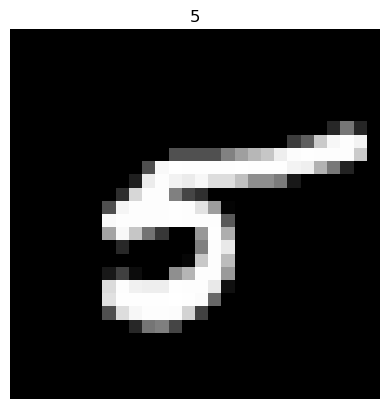

In [12]:
visualiser_image(images_train, labels_train)

## Analyse en composantes principales

On se limite pour le moment à un cas de classification binaire en ne conservant que les 4 et les 7:

In [13]:
valeur_1, valeur_2 = 4, 7

In [14]:
mask = (labels_train == valeur_1) | (labels_train == valeur_2)
images01_train = images_train[mask]
labels01_train = labels_train[mask]
n = images01_train.shape[0]

In [15]:
mask = (labels_test == valeur_1) | (labels_test == valeur_2)
images01_test = images_test[mask]
labels01_test = labels_test[mask]

In [16]:
n, images01_train.shape, labels01_train.shape, images01_test.shape, labels01_test.shape

(12107, (12107, 784), (12107,), (2010, 784), (2010,))

On centre les images en soustrayant la moyenne (on calcule la moyenne uniquement sur les données d'apprentissage !):

In [17]:
images01_mean = images01_train.mean(axis=0)
images01_mean.shape

(784,)

In [18]:
images01_train_centrees = images01_train - images01_mean
images01_test_centrees = images01_test - images01_mean

On commence avec une décomposition en valeurs singulières (SVD):

In [19]:
V, S, Ut = sp.linalg.svd(images01_train_centrees, full_matrices=False)
U = Ut.T

On a vu en TD que la matrice de covariance des colonnes $\Sigma$:

$$
    \Sigma = \frac{1}{n} U S^2 U^T
$$

Par conséquent (décomposition spectrale la matrice $\Sigma$ et identification):

$$
    \Lambda = \frac{1}{n} S^2
$$

Les valeurs singulières sont déjà triées par valeur décroissante. Mais si on avait voulu trier les valeurs propres et les vecteurs propres:

In [20]:
tri = np.argsort(S)[::-1]
S = S[tri]
U = U[tri, :]

On calcule les valeurs propres:

In [21]:
lbd = 1 / n * S**2

On trace l'éboulis des valeurs propres:

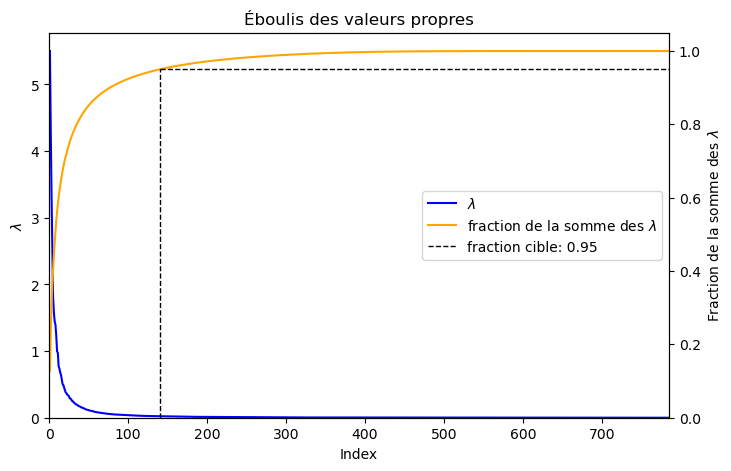

In [22]:
trace_eboulis(lbd)

On conserverait 95% de la variance en conservant les 150 premières composantes.

## Arbre seul

On étudie un arbre de décision avec un critère entropie comme vu en cours. La profondeur évoquée en cours correspond à l'argument `max_depth`. La taille minimum de feuille évoquée en cours correspond à `min_samples_split`. Dans cette implémentation il n'y a pas de critère d'entropie minimale. On se limitera alors à ces deux hyper-paramètres:

In [23]:
tree = DecisionTreeClassifier(criterion='entropy', max_depth=2, min_samples_split=2)

In [24]:
tree.fit(images01_train_centrees, labels01_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

On regarde maintenant la performance de notre algorithme avec une courbe ROC. Les données sont à peu près équilbrées dans les données d'apprentissage et de test:

In [25]:
labels01_train[labels01_train == valeur_1].shape[0], labels01_train[labels01_train == valeur_1].shape[0]

(5842, 5842)

In [26]:
labels01_test[labels01_test == valeur_2].shape[0], labels01_test[labels01_test == valeur_2].shape[0]

(1028, 1028)

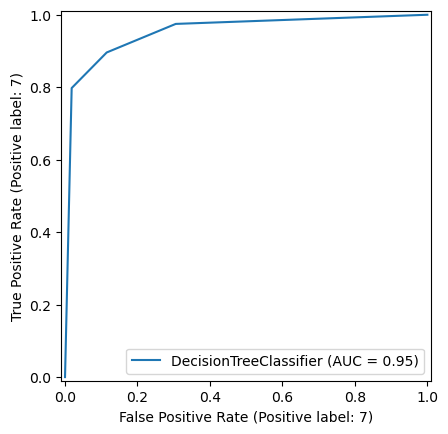

In [27]:
RocCurveDisplay.from_estimator(tree, images01_test_centrees, labels01_test);

Le classifieur se comporte raisonnablement bien.

## Arbres et ACP

On combine maintenant un arbre avec une analyse en composantes principales conservant les 150 premières composantes (95% de la variance):

In [28]:
pca = PCA(150)  # on utilisera sklearn maintenant. Mais derrière c'est la décomposition SVD qui est utilisée, comme plus haut

On garde le même arbre que précédemment:

In [29]:
tree = DecisionTreeClassifier(criterion='entropy', max_depth=2, min_samples_split=2)

On utilise une pipeline sklearn pour combiner l'ACP et l'arbre:

In [30]:
pipeline = Pipeline([("ACP", pca), ("arbre", tree)])
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('ACP', ...), ('arbre', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",150
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.li

On entraine l'ACP et l'arbre en même temps grâce à la pipeline:

In [31]:
pipeline.fit(images01_train_centrees, labels01_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('ACP', ...), ('arbre', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",150
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.li

On regarde maintenant la performance de notre algorithme avec une courbe ROC. Les données sont à peu près équilbrées dans les données d'apprentissage et de test:

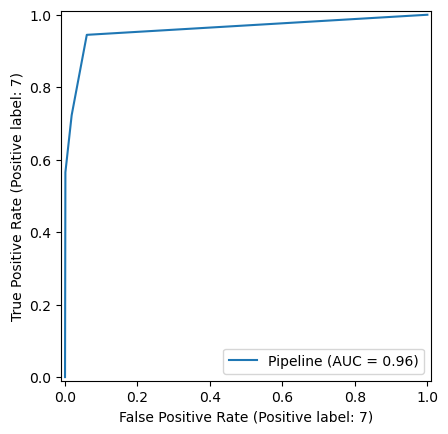

In [32]:
RocCurveDisplay.from_estimator(pipeline, images01_test_centrees, labels01_test);

On note un petit gain de performance (AUC meilleure) en utilisant la PCA.

Le grand avantage des arbres de décisions et la capacité à comprendre comment ils réalisent leurs prédictions:

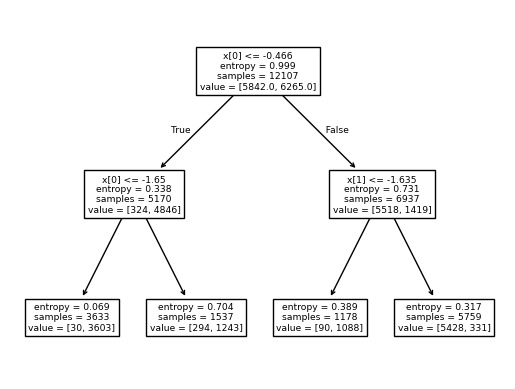

In [33]:
plot_tree(pipeline["arbre"]);

On voit par exemple ici que l'arbre n'a réalisé que des découpages le long des 2 premières composantes principales. Donc techniquement on pourrait limiter l'ACP aux deux premières composantes et on obtiendrait les mêmes résultats:

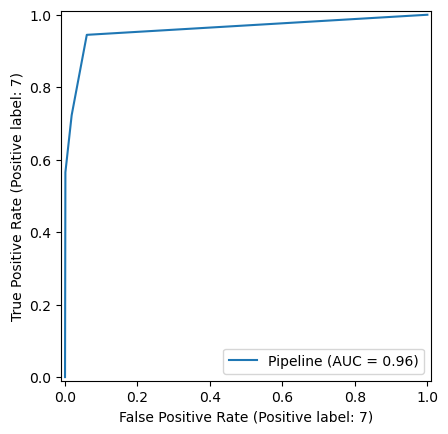

In [34]:
pca = PCA(2)
tree = DecisionTreeClassifier(criterion='entropy', max_depth=2, min_samples_split=2)
pipeline.fit(images01_train_centrees, labels01_train)
RocCurveDisplay.from_estimator(pipeline, images01_test_centrees, labels01_test);

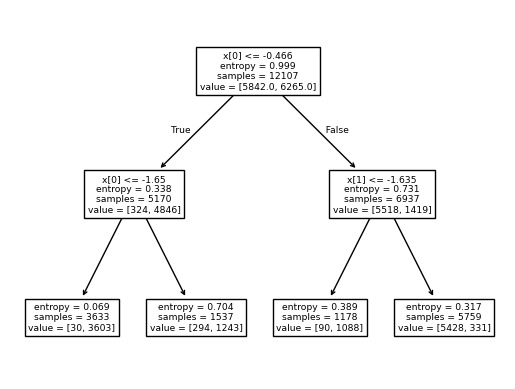

In [35]:
plot_tree(pipeline["arbre"]);

C'est bien le cas ! Pour bien comprendre ce qu'il se passe on peut visualiser les scores de ces 2 composantes principales:

In [36]:
scores_acp = pipeline["ACP"].transform(images01_test_centrees)

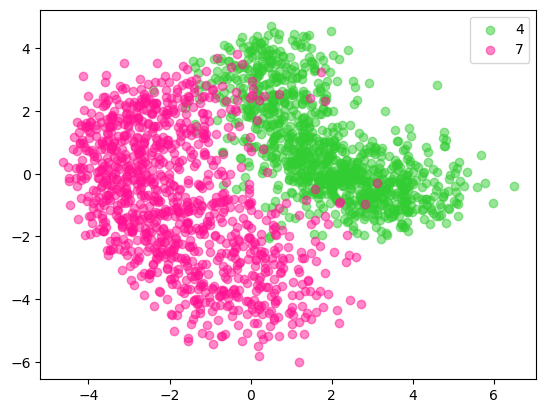

In [37]:
plt.scatter(scores_acp[labels01_test == valeur_1, 0], scores_acp[labels01_test == valeur_1, 1], color="limegreen", alpha=0.5, label=f"{valeur_1}")
plt.scatter(scores_acp[labels01_test == valeur_2, 0], scores_acp[labels01_test == valeur_2, 1], color="deeppink", alpha=0.5, label=f"{valeur_2}")
plt.legend();

Non seulement l'ACP a réduit le nombre de dimensions mais elle permet également de "séparer" les données. Ce qui facilite le travail de l'algorithme de classification.

## Classification multiple avec arbre et ACP

Nous passons maintenant à une classification multiple:

In [38]:
images_mean = images_train.mean(axis=0)
images_mean.shape

(784,)

In [39]:
images_train_centrees = images_train - images_mean
images_test_centrees = images_test - images_mean

Comme il y a maintenant 10 classes on va augmenter la profondeur pour qu'il y ait au moins 10 feuilles:

In [40]:
pca = PCA(150)
tree = DecisionTreeClassifier(criterion='entropy', max_depth=4, min_samples_split=2)

In [41]:
pipeline = Pipeline([("ACP", pca), ("arbre", tree)])

In [42]:
pipeline.fit(images_train_centrees, labels_train);

Dans sklearn, `RocCurveDisplay` ne gère qu'un cas de classification binaire. L'astuce consiste donc à tracer 1 courbe ROC par label (10 en tout donc pour 0, 1, ..., 9) en faisant du "one versus rest":

- Si la classe vraie est "0":
  - Si l'algorithme prédit "0": vrai positif
  - Si l'algorithme prédit autre chose: faux négatif
- Si la classe vraie est autre chose que "0":
  - Si l'algorithme prédit autre chose que "0": vrai négatif
  - Si l'algorithme prédit "0": faux positif
  
Ce traitement est facilité par `LabelBinarizer`:

In [43]:
labels_train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

In [44]:
binarizer = LabelBinarizer()
binarizer.fit(labels_train)

,"neg_label neg_label: int, default=0Value with which negative labels must be encoded.",0
,"pos_label pos_label: int, default=1Value with which positive labels must be encoded.",1
,"sparse_output sparse_output: bool, default=FalseTrue if the returned array from transform is desired to be in sparseCSR format.",False


In [45]:
labels_test_bin = binarizer.transform(labels_test)

On calcule maintenant la prédiction du modèle sur les données de test, les probabilités de chaque classe pour être précis:

In [46]:
y_score = pipeline.predict_proba(images_test_centrees)

On trace toutes les courbes ROC:

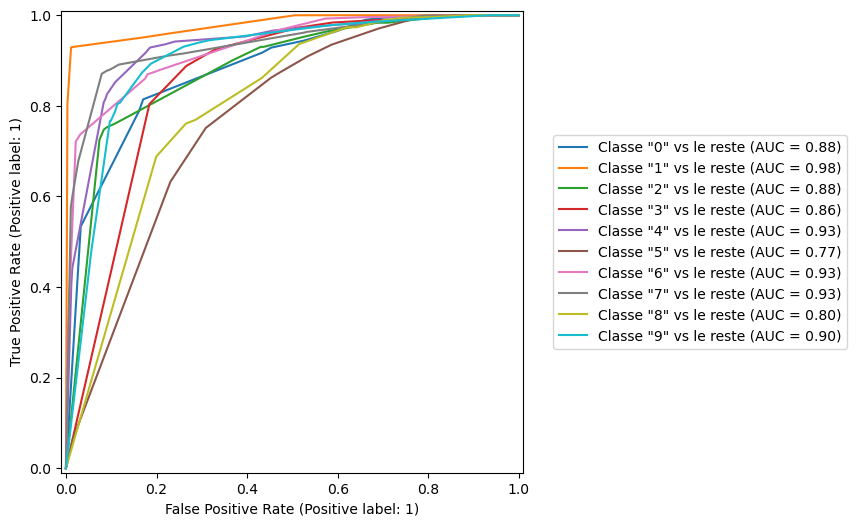

In [47]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111)
for i in range(10):
    RocCurveDisplay.from_predictions(y_true=labels_test_bin[:,i], y_score=y_score[:,i], ax=ax, name=f"Classe \"{i}\" vs le reste")
ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5));

C'est beaucoup moins bien qu'avec deux classes. Notre arbre simple ne suffit plus.

Regardons ce que fait notre arbre:

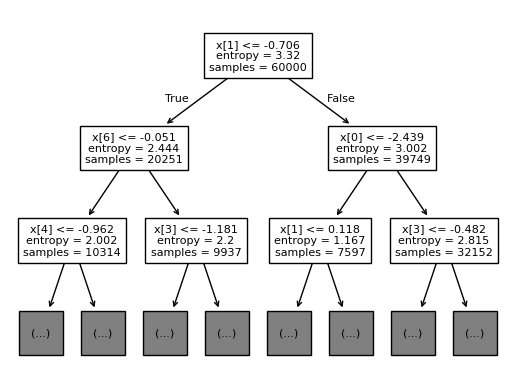

In [48]:
annotations = plot_tree(pipeline["arbre"], max_depth=2, fontsize=8)
for annotation in annotations:
    texte_actuel = annotation.get_text()
    lignes = texte_actuel.split('\n')    
    # On filtre: on garde les lignes jusqu'à samples
    lignes_filtrees = []
    for ligne in lignes:
        lignes_filtrees.append(ligne)
        if "samples" in ligne:
            break
    annotation.set_text('\n'.join(lignes_filtrees))
plt.show()

La première découpe se fait le long de la seconde composante et les deux suivantes selon la composante principale et la 7ème composante.

Regardons ce qui se passe sur les 2 premières composantes de l'ACP:

In [49]:
scores_acp = pipeline["ACP"].transform(images_test_centrees)

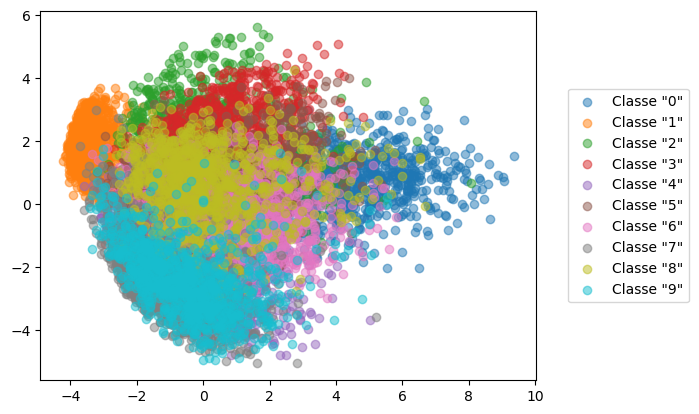

In [50]:
for i in range(10):
    plt.scatter(scores_acp[labels_test == i, 0], scores_acp[labels_test == i, 1], alpha=0.5, label=f"Classe \"{i}\"")
plt.legend(loc="center left", bbox_to_anchor=(1.05, 0.5));

Les classes sont toutes mélangées ! Le travail de découpage est donc maintenant beaucoup plus difficile.

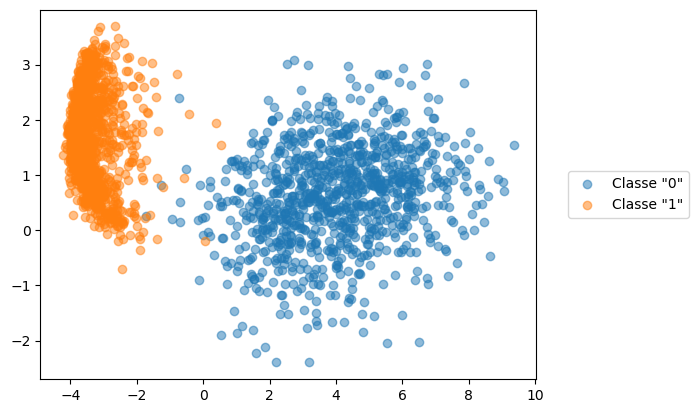

In [51]:
for i in [0, 1]:
    plt.scatter(scores_acp[labels_test == i, 0], scores_acp[labels_test == i, 1], alpha=0.5, label=f"Classe \"{i}\"")
plt.legend(loc="center left", bbox_to_anchor=(1.05, 0.5));

Les classes "0" et "1" sont très bien séparées.

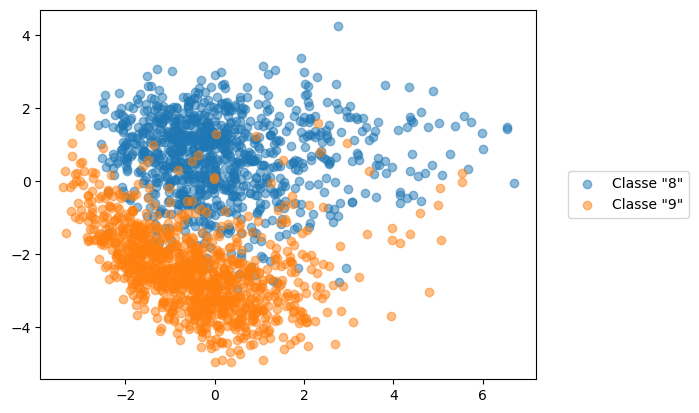

In [52]:
for i in [8, 9]:
    plt.scatter(scores_acp[labels_test == i, 0], scores_acp[labels_test == i, 1], alpha=0.5, label=f"Classe \"{i}\"")
plt.legend(loc="center left", bbox_to_anchor=(1.05, 0.5));

Les classes "8" et "9" se retrouvent, deux à deux, bien séparées.

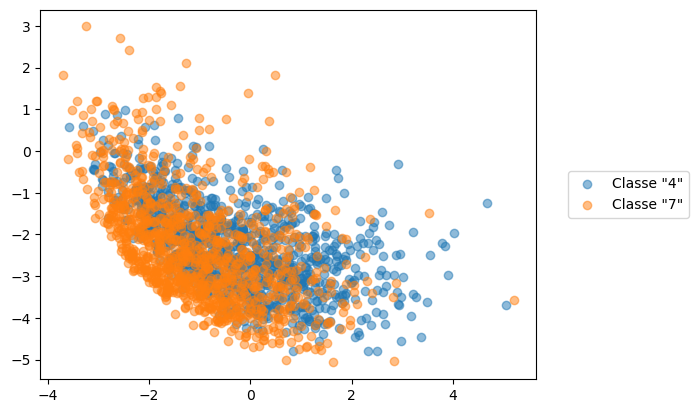

In [53]:
for i in [4, 7]:
    plt.scatter(scores_acp[labels_test == i, 0], scores_acp[labels_test == i, 1], alpha=0.5, label=f"Classe \"{i}\"")
plt.legend(loc="center left", bbox_to_anchor=(1.05, 0.5));

Les classes "4" et "7", en revanche, se retrouvent emmêlées. Alors que lorsque nous n'avions que des 4 et des 7, l'ACP avait réussi à les partager.

## Arbre et ACP avec optimisation des hyper-paramètres

Dans cette section on introduit une optimisation des hyper-paramètres:

- le nombre de composantes de l'analyse en composantes principales
- la profondeur maximale de l'arbre


On fixera la taille minimum des feuilles à 2.

On va utiliser un algorithme de validation croisée: l'algorithme des K-plis. Cet algorithme va être combinée à une recherche des hyper-paramètres en grille:

- On va lister différentes options pour chacun des hyper-paramètres.
- Pour chaque combinaison de ces hyper-paramètres on va utiliser la validation croisée en K-plis pour évaluer la performance de ces hyper-paramètres.
- A la fin, on pourra sélectionner les hyper-paramètres apportant la meilleure performance sur les K-plis.
- On testera notre modèle sur les données de test pour tracer les courbes ROC

On converve notre pipeline:

In [54]:
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('ACP', ...), ('arbre', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",150
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.li

Cette pipeline dispose de paramètres:

In [55]:
pipeline.get_params()

{'memory': None,
 'steps': [('ACP', PCA(n_components=150)),
  ('arbre', DecisionTreeClassifier(criterion='entropy', max_depth=4))],
 'transform_input': None,
 'verbose': False,
 'ACP': PCA(n_components=150),
 'arbre': DecisionTreeClassifier(criterion='entropy', max_depth=4),
 'ACP__copy': True,
 'ACP__iterated_power': 'auto',
 'ACP__n_components': 150,
 'ACP__n_oversamples': 10,
 'ACP__power_iteration_normalizer': 'auto',
 'ACP__random_state': None,
 'ACP__svd_solver': 'auto',
 'ACP__tol': 0.0,
 'ACP__whiten': False,
 'arbre__ccp_alpha': 0.0,
 'arbre__class_weight': None,
 'arbre__criterion': 'entropy',
 'arbre__max_depth': 4,
 'arbre__max_features': None,
 'arbre__max_leaf_nodes': None,
 'arbre__min_impurity_decrease': 0.0,
 'arbre__min_samples_leaf': 1,
 'arbre__min_samples_split': 2,
 'arbre__min_weight_fraction_leaf': 0.0,
 'arbre__monotonic_cst': None,
 'arbre__random_state': None,
 'arbre__splitter': 'best'}

On ne s'interessera qu'à ceux-là:

- `ACP__n_components`: nombre de composantes principales
- `arbre__max_depth`: profondeur maximale de l'arbre
- `arbre__min_samples_split`: taille minimum des feuilles

Noter que les paramètres sont nommés en fonction des noms (ACP, arbre) passés à notre pipeline plus haut, combinés au nom des arguments des algorithmes sklearn.

On définit une liste de valeurs que l'on souhaite explorer:

In [56]:
# Eviter d'être trop gourmands ;) Plus les listes sont longues plus l'ordinateur va travailler. Et plus il va falloir être patients.
params = {
    "ACP__n_components": [64, 128],
    "arbre__max_depth": [4, 8, 16],
    "arbre__min_samples_split": [2]
}

On configure l'algorithme de recherche sur grille avec validation croisée à 5 plis (pour limiter les calculs):

In [57]:
grid = GridSearchCV(
    pipeline,               # on passe notre pipeline ici
    params,                 # les paramètres que l'on souhaite explorer
    cv=5,                   # méthode de validation croisée à 10 plis
    scoring='roc_auc_ovr',  # on précise ici que l'on cherche à optimiser l'AUC de la courbe ROC utilisant le one vs rest
    refit=True,             # une fois les meilleurs paramètres trouvés, on recalibre le modèle avec sur toutes les données
    n_jobs=-1,              # si notre PC a plusieurs CPU, permet de paralléliser. -1 utilise tous les CPU disponibles
    verbose=4,              # pour suivre l'avancement des calculs (suivre la console depuis laquelle vous avez lancé le notebook)
)

On calibre notre pipeline:

In [58]:
grid.fit(images_train_centrees, labels_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ax_depth=4))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ACP__n_components': [64, 128], 'arbre__max_depth': [4, 8, ...], 'arbre__min_samples_split': [2]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc_ovr'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is di

On analyse les résultats:

In [59]:
df = pd.DataFrame(grid.cv_results_)
df.head(6)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_ACP__n_components,param_arbre__max_depth,param_arbre__min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,19.653480,2.567647,0.193432,0.024035,64,4,2,"{'ACP__n_components': 64, 'arbre__max_depth': ...",0.890652,0.879277,0.886552,0.884444,0.898279,0.887841,0.006378,5
1,31.360978,2.788388,0.191922,0.034616,64,8,2,"{'ACP__n_components': 64, 'arbre__max_depth': ...",0.959129,0.958167,0.956067,0.956577,0.962423,0.958472,0.002259,1
2,34.248307,3.177628,0.208770,0.044978,64,16,2,"{'ACP__n_components': 64, 'arbre__max_depth': ...",0.916714,0.908569,0.907287,0.906979,0.918107,0.911531,0.004850,3
3,29.102408,2.651074,0.275529,0.033962,128,4,2,"{'ACP__n_components': 128, 'arbre__max_depth':...",0.890652,0.879277,0.886552,0.884444,0.898279,0.887841,0.006378,5
4,42.198912,1.643313,0.201858,0.011015,128,8,2,"{'ACP__n_components': 128, 'arbre__max_depth':...",0.959303,0.957476,0.955492,0.955849,0.962036,0.958031,0.002415,2
5,47.212436,1.440206,0.176845,0.020381,128,16,2,"{'ACP__n_components': 128, 'arbre__max_depth':...",0.913807,0.904658,0.905100,0.904142,0.913868,0.908315,0.004519,4


Les colonnes `time` indique le temps de calcul pour l'apprentissage (fit) ou pour le test (score). Le tableau résume les valeurs des différents paramètres. Les `split_test_score` donne les scores calculés (ce sont les AUC en mode one vs rest) moyennés sur toutes les classes pour chaque pli. Le `mean_score` est le score moyen sur l'ensemble des plis. Enfin, `rank_test_score` permet d'identifier les meilleurs configurations.

Dans cet exemple 64 composantes et une profondeur de 8 obtiennent de très bons résultats, tout comme 128 composantes et une profondeur de 8. Le modèle avec 64 composantes est plus simple alors cela tombe bien qu'il ait un meilleur score.

Pour en savoir plus sur le meilleur estimateur trouvé:

In [60]:
grid.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('ACP', ...), ('arbre', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",64
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.lin

Comme le meilleur algorithme a été ré-entrainé, on peut directement regarder la courbe ROC:

In [61]:
y_score = grid.best_estimator_.predict_proba(images_test_centrees)

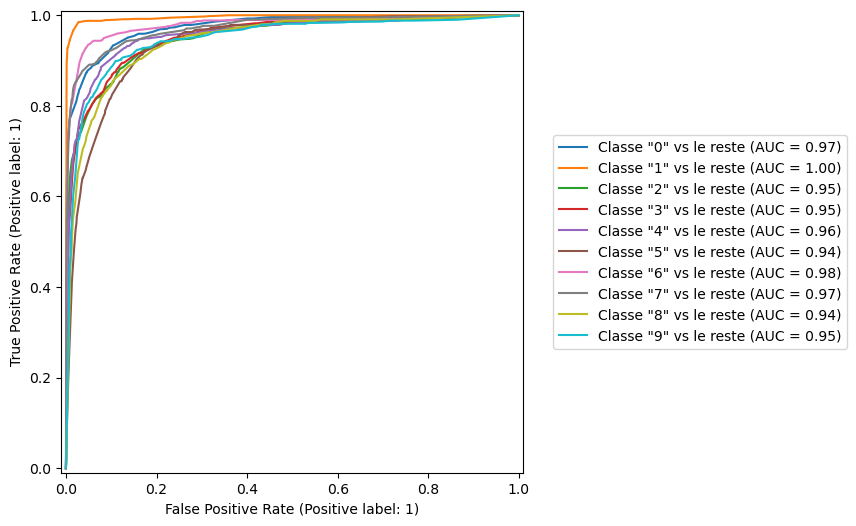

In [62]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111)
for i in range(10):
    RocCurveDisplay.from_predictions(y_true=labels_test_bin[:,i], y_score=y_score[:,i], ax=ax, name=f"Classe \"{i}\" vs le reste")
ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5));

C'est mieux que ce que l'on avait précédemment !

## Forêt Aléatoire (bagging) et ACP

Nous nous intéressons désormais au bagging et à l'algorithme des forêts aléatoires. L'algorithme d'ACP est assez lent sur ces données. Nous utiliserons donc une astuce pour économiser le coût de l'ACP. L'astuce consiste à créer une classe utilisateur implémentant les méthodes fit et transform:

In [63]:
class SelectKComponents(BaseEstimator, TransformerMixin):
    def __init__(self, n_components=10):
        self.n_components = n_components
        
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        return X[:, :self.n_components]

**Attention !** ce n'est pas très rigoureux. Idéalement il faudrait refaire l'ACP pour chaque pli de la validation croisée. C'est une liberté prise ici pour limiter le temps de calcul.

In [64]:
pca = PCA(784)
pca.fit(images_train_centrees)
images_train_compressed = pca.transform(images_train_centrees)

In [65]:
select = SelectKComponents()

In [66]:
forest = RandomForestClassifier(
    criterion="entropy",  # pour rester sur ce que l'on a vu en cours
    min_samples_split=2,  # taille de feuille minimum
    # à chaque découpe, utilise un maximum de sqrt(d) caractéristiques sur les d possibles: addition de RandomForest par rapport à un bagging pur
    max_features="sqrt",  
)

In [67]:
pipeline = Pipeline([("ACP", select), ("foret", forest)])
pipeline.get_params()

{'memory': None,
 'steps': [('ACP', SelectKComponents()),
  ('foret', RandomForestClassifier(criterion='entropy'))],
 'transform_input': None,
 'verbose': False,
 'ACP': SelectKComponents(),
 'foret': RandomForestClassifier(criterion='entropy'),
 'ACP__n_components': 10,
 'foret__bootstrap': True,
 'foret__ccp_alpha': 0.0,
 'foret__class_weight': None,
 'foret__criterion': 'entropy',
 'foret__max_depth': None,
 'foret__max_features': 'sqrt',
 'foret__max_leaf_nodes': None,
 'foret__max_samples': None,
 'foret__min_impurity_decrease': 0.0,
 'foret__min_samples_leaf': 1,
 'foret__min_samples_split': 2,
 'foret__min_weight_fraction_leaf': 0.0,
 'foret__monotonic_cst': None,
 'foret__n_estimators': 100,
 'foret__n_jobs': None,
 'foret__oob_score': False,
 'foret__random_state': None,
 'foret__verbose': 0,
 'foret__warm_start': False}

Ici, on essaie d'optimiser la pipeline sur les paramètres suivants:

- ACP__n_components: nombre de composantes principales à conserver
- foret__max_depth: profondeur maximale des arbres
- foret__n_estimators: nombre d'arbres à entraîner dans la forêt aléatoire

In [68]:
# On peut être un peu plus gourmands ici vu que l'ACP qui est le plus long à calculer a été sortiee de la pipeline
params = {
    "ACP__n_components": [8, 16, 32],
    "foret__max_depth": [4, 8, 16],
    "foret__n_estimators": [8, 16, 32]
}

On configure l'algorithme de recherche sur grille avec validation croisée à 5 plis (pour limiter les calculs):

In [69]:
grid = GridSearchCV(
    pipeline,               # on passe notre pipeline ici
    params,                 # les paramètres que l'on souhaite explorer
    cv=5,                   # méthode de validation croisée à 10 plis
    scoring='roc_auc_ovr',  # on précise ici que l'on cherche à optimiser l'AUC de la courbe ROC utilisant le one vs rest
    refit=False,            # on choisira nous même le modèle
    n_jobs=-1,              # si notre PC a plusieurs CPU, permet de paralléliser. -1 utilise tous les CPU disponibles
    verbose=4,              # pour suivre l'avancement des calculs (suivre la console depuis laquelle vous avez lancé le notebook)
)

In [70]:
grid.fit(images_train_compressed, labels_train);

Fitting 5 folds for each of 27 candidates, totalling 135 fits


On analyse les résultats:

In [71]:
df = pd.DataFrame(grid.cv_results_)
df.sort_values("rank_test_score", ascending = True, inplace=True)  # trie les résultats par performance
df.head(10)  # affiche les 10 meilleurs

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_ACP__n_components,param_foret__max_depth,param_foret__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
26,32.755672,1.779417,0.099476,0.011343,32,16,32,"{'ACP__n_components': 32, 'foret__max_depth': ...",0.996733,0.996634,0.996330,0.996503,0.996489,0.996538,0.000137,1
17,37.711422,2.423441,0.219546,0.086211,16,16,32,"{'ACP__n_components': 16, 'foret__max_depth': ...",0.995897,0.995643,0.995589,0.995085,0.995704,0.995583,0.000270,2
25,22.871928,1.403473,0.086711,0.010521,32,16,16,"{'ACP__n_components': 32, 'foret__max_depth': ...",0.994799,0.994621,0.993840,0.994525,0.995405,0.994638,0.000503,3
16,16.517632,0.336233,0.092534,0.020590,16,16,16,"{'ACP__n_components': 16, 'foret__max_depth': ...",0.994164,0.993681,0.993254,0.993287,0.994055,0.993688,0.000377,4
8,18.591993,1.135056,0.185367,0.058007,8,16,32,"{'ACP__n_components': 8, 'foret__max_depth': 1...",0.990049,0.989131,0.989049,0.988563,0.990730,0.989504,0.000779,5
24,12.393222,1.013458,0.083469,0.016055,32,16,8,"{'ACP__n_components': 32, 'foret__max_depth': ...",0.989110,0.988899,0.989321,0.989020,0.990357,0.989341,0.000526,6
15,8.756582,0.279340,0.066623,0.005124,16,16,8,"{'ACP__n_components': 16, 'foret__max_depth': ...",0.989689,0.988681,0.988908,0.988191,0.989879,0.989070,0.000630,7
23,34.187370,1.886133,0.110613,0.025999,32,8,32,"{'ACP__n_components': 32, 'foret__max_depth': ...",0.988541,0.986863,0.987008,0.987098,0.988859,0.987674,0.000847,8
7,9.544150,0.800585,0.097219,0.012183,8,16,16,"{'ACP__n_components': 8, 'foret__max_depth': 1...",0.986416,0.986601,0.986237,0.985914,0.988167,0.986667,0.000783,9
14,24.790479,0.448477,0.103332,0.010116,16,8,32,"{'ACP__n_components': 16, 'foret__max_depth': ...",0.986687,0.985062,0.985755,0.985280,0.987547,0.986066,0.000927,10


Tous ces modèles ont des AUC One vs Rest au dessus de 0.98. Très souvent, une profondeur d'arbre de 16 a été sélectionnée. Mais il y a un arbre avec 8 estimateurs et 32 composantes plus simple que les autres et un autre avec 16 arbres et 16 composantes. On va préférer une de ces alternatives pour leur simplicité relative. De préférence celle avec les réglages les plus agressifs sur les arbres puisque c'est l'intérêt des forêts aléatoires.

In [72]:
select = SelectKComponents(16)
forest = RandomForestClassifier(
    criterion="entropy",  # pour rester sur ce que l'on a vu en cours
    min_samples_split=2,  # taille de feuille minimum
    # à chaque découpe, utilise un maximum de sqrt(d) caractéristiques sur les d possibles: addition de RandomForest par rapport à un bagging pur
    max_features="sqrt",  
    max_depth=16,
    n_estimators=16
)
pipeline = Pipeline([("ACP", select), ("foret", forest)])
pipeline.fit(images_train_compressed, labels_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('ACP', ...), ('foret', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,n_components,16
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",16
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",16
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0


Vérifions la performance sur les données de test. Ne pas oublier d'appliquer la compression sur les données de test !

In [73]:
y_score = pipeline.predict_proba(pca.transform(images_test_centrees))

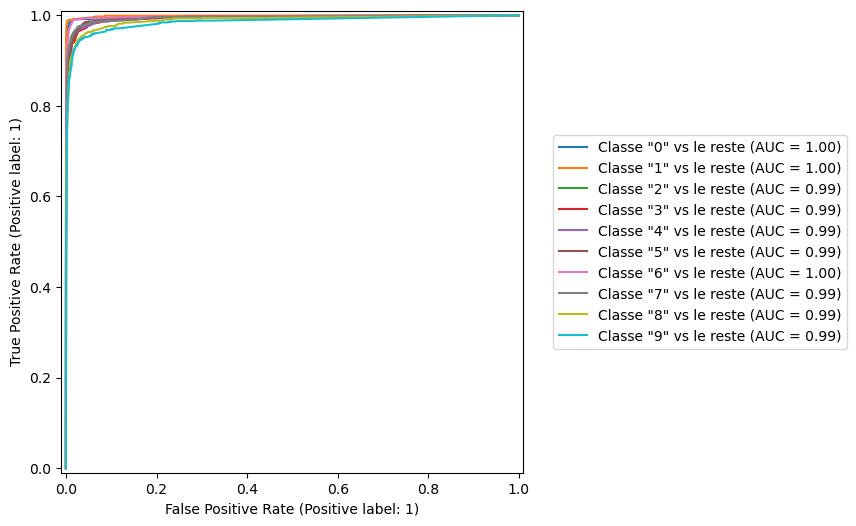

In [74]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111)
for i in range(10):
    RocCurveDisplay.from_predictions(y_true=labels_test_bin[:,i], y_score=y_score[:,i], ax=ax, name=f"Classe \"{i}\" vs le reste")
ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5));

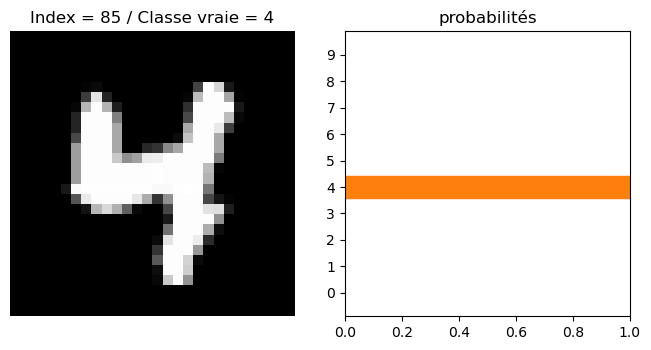

In [75]:
visualiser_image_classification(images_test, labels_test, y_score, index=None)

On obtient un meilleur modèle avec les forêts aléatoires.

## Arbres et boosting avec AdaBoost

On teste maintenant une alternative ensembliste avec le boosting et AdaBoost. Comme AdaBoost peut fonctionner avec différents algorithmes de classification, on crée tout d'abord un arbre type:

In [76]:
tree = DecisionTreeClassifier(
    criterion="entropy",  # pour rester sur ce que l'on a vu en cours
    min_samples_split=2,  # taille de feuille minimum
)

Maintenant on crée un algorithme de boosting qui utilisera cet arbre type:

In [77]:
boost = AdaBoostClassifier(
    tree,  # on passe notre estimateur arbre de décision type
    learning_rate = 1.0,  # on fixe la valeur mais on aurait pu optimiser
)

Et maintenant notre pipeline:

In [78]:
pipeline = Pipeline([("ACP", SelectKComponents()), ("boost", boost)])  # pas la peine de passer l'arbre ici, il est inclus dans le boosting.

In [79]:
pipeline.get_params()

{'memory': None,
 'steps': [('ACP', SelectKComponents()),
  ('boost',
   AdaBoostClassifier(estimator=DecisionTreeClassifier(criterion='entropy')))],
 'transform_input': None,
 'verbose': False,
 'ACP': SelectKComponents(),
 'boost': AdaBoostClassifier(estimator=DecisionTreeClassifier(criterion='entropy')),
 'ACP__n_components': 10,
 'boost__estimator__ccp_alpha': 0.0,
 'boost__estimator__class_weight': None,
 'boost__estimator__criterion': 'entropy',
 'boost__estimator__max_depth': None,
 'boost__estimator__max_features': None,
 'boost__estimator__max_leaf_nodes': None,
 'boost__estimator__min_impurity_decrease': 0.0,
 'boost__estimator__min_samples_leaf': 1,
 'boost__estimator__min_samples_split': 2,
 'boost__estimator__min_weight_fraction_leaf': 0.0,
 'boost__estimator__monotonic_cst': None,
 'boost__estimator__random_state': None,
 'boost__estimator__splitter': 'best',
 'boost__estimator': DecisionTreeClassifier(criterion='entropy'),
 'boost__learning_rate': 1.0,
 'boost__n_estimat

Ici, on essaie d'optimiser la pipeline sur les paramètres suivants:

- ACP__n_components: nombre de composantes principales à conserver
- boost__n_estimators: nombre d'arbres à entraîner dans le boosting
- boost__estimator__max_depth: profondeur maximale de l'arbre

In [80]:
# Attention, entraîner un AdaBoost prend du temps !
params = {
    "ACP__n_components": [16, 32],
    "boost__estimator__max_depth": [1, 2],  # chaque arbre aura un biais très important
    "boost__n_estimators": [16, 32, 64]
}

On configure l'algorithme de recherche sur grille avec validation croisée à 5 plis (pour limiter les calculs):

In [81]:
grid = GridSearchCV(
    pipeline,               # on passe notre pipeline ici
    params,                 # les paramètres que l'on souhaite explorer
    cv=5,                   # méthode de validation croisée à 10 plis
    scoring='roc_auc_ovr',  # on précise ici que l'on cherche à optimiser l'AUC de la courbe ROC utilisant le one vs rest
    refit=False,            # on choisira nous même le modèle
    n_jobs=-1,              # si notre PC a plusieurs CPU, permet de paralléliser. -1 utilise tous les CPU disponibles
    verbose=4,              # pour suivre l'avancement des calculs (suivre la console depuis laquelle vous avez lancé le notebook)
)

In [82]:
grid.fit(images_train_compressed, labels_train);

Fitting 5 folds for each of 12 candidates, totalling 60 fits


On analyse les résultats:

In [83]:
df = pd.DataFrame(grid.cv_results_)
df.sort_values("rank_test_score", ascending = True, inplace=True)  # trie les résultats par performance
df.head(10)  # affiche les 10 meilleurs

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_ACP__n_components,param_boost__estimator__max_depth,param_boost__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
11,143.264972,7.750355,0.237032,0.037935,32,2,64,"{'ACP__n_components': 32, 'boost__estimator__m...",0.955241,0.950590,0.950874,0.952156,0.960230,0.953818,0.003605,1
5,89.732450,1.357061,0.295824,0.036094,16,2,64,"{'ACP__n_components': 16, 'boost__estimator__m...",0.955427,0.949095,0.948573,0.954887,0.957727,0.953142,0.003648,2
4,45.820600,0.920548,0.165474,0.017824,16,2,32,"{'ACP__n_components': 16, 'boost__estimator__m...",0.944557,0.931021,0.931812,0.937975,0.944011,0.937875,0.005763,3
10,89.271311,1.895073,0.201759,0.014803,32,2,32,"{'ACP__n_components': 32, 'boost__estimator__m...",0.941211,0.933556,0.936207,0.929357,0.944976,0.937061,0.005518,4
8,91.516236,1.724670,0.403534,0.015224,32,1,64,"{'ACP__n_components': 32, 'boost__estimator__m...",0.915172,0.916084,0.908159,0.921659,0.923428,0.916900,0.005391,5
2,48.269170,1.958614,0.324513,0.071671,16,1,64,"{'ACP__n_components': 16, 'boost__estimator__m...",0.915172,0.915646,0.908159,0.920433,0.922654,0.916413,0.005007,6
9,45.509339,2.351984,0.155400,0.006335,32,2,16,"{'ACP__n_components': 32, 'boost__estimator__m...",0.927734,0.899384,0.909097,0.911919,0.924000,0.914427,0.010293,7
3,23.857950,1.207193,0.115617,0.010780,16,2,16,"{'ACP__n_components': 16, 'boost__estimator__m...",0.921568,0.899854,0.909097,0.915457,0.924000,0.913995,0.008758,8
1,24.909983,1.115125,0.177190,0.021653,16,1,32,"{'ACP__n_components': 16, 'boost__estimator__m...",0.884061,0.879324,0.869661,0.896211,0.896300,0.885111,0.010214,9
7,46.442561,1.077415,0.221779,0.028710,32,1,32,"{'ACP__n_components': 32, 'boost__estimator__m...",0.884061,0.879324,0.869661,0.896211,0.896300,0.885111,0.010214,9


On sélectionnera ici la configuration avec 16 composantes principales, une profondeur de 2 et 64 estimateurs:

In [84]:
select = SelectKComponents(16)
tree = DecisionTreeClassifier(
    criterion="entropy",  # pour rester sur ce que l'on a vu en cours
    min_samples_split=2,  # taille de feuille minimum
    max_depth=2,  # valeur optimale trouvée
)
boost = AdaBoostClassifier(
    tree,  # on passe notre estimateur arbre de décision type
    learning_rate=1.0,  # on fixe la valeur mais on aurait pu optimiser
    n_estimators=64,  # valeur optimale trouvée,
)
pipeline = Pipeline([("ACP", select), ("boost", boost)])
pipeline.fit(images_train_compressed, labels_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('ACP', ...), ('boost', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,n_components,16
,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.","DecisionTreeC..., max_depth=2)"
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",64
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'


Vérifions la performance sur les données de test. Ne pas oublier d'appliquer la compression sur les données de test !

In [85]:
y_score = pipeline.predict_proba(pca.transform(images_test_centrees))

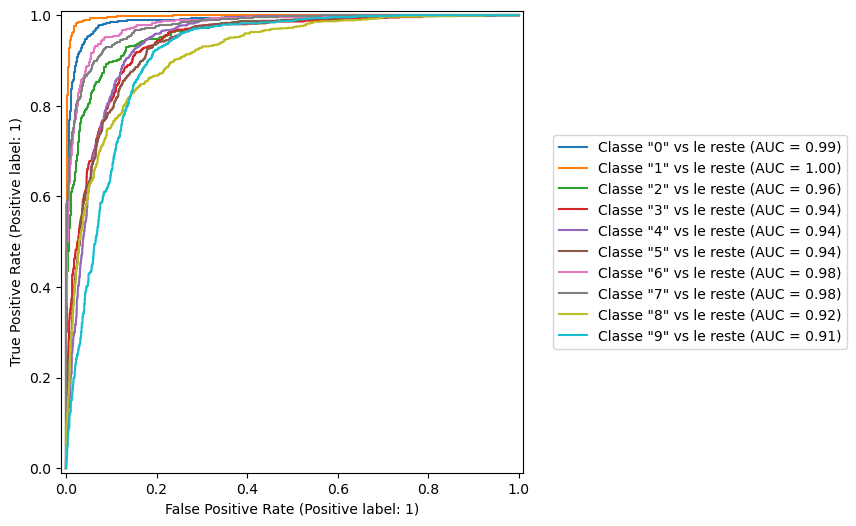

In [86]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111)
for i in range(10):
    RocCurveDisplay.from_predictions(y_true=labels_test_bin[:,i], y_score=y_score[:,i], ax=ax, name=f"Classe \"{i}\" vs le reste")
ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5));

C'est un peu moins bien qu'avec les forêts aléatoires mais cela reste correct.

Visualisez quelques résultats de classification d'images, remarquez vous quelque chose de surprenant ?

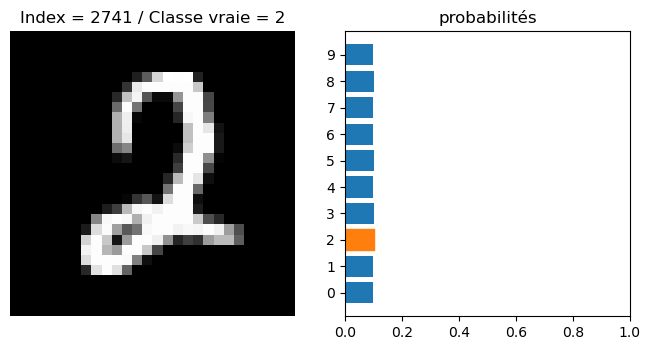

In [87]:
visualiser_image_classification(images_test, labels_test, y_score, index=None)

Très souvent, la probabilité prédite est plus grande pour la classe vraie, mais la probabilité reste très faible ! AdaBoost ne cherche pas à **maximiser** la probabilité de la classe vraie, il cherche juste à la rendre marginalement plus grande que les autres.

Dans ce problème à 10 classes, il n'y a pas assez de découpe dans chaque arbre pour "ranger" 10 classes. Le biais est donc énorme. Et il n'y a pas assez d'estimateurs pour contre-balancer le biais. Ou alors il faudrait avoir un temps d'entraînement beaucoup plus important. Une autre solution serait d'augmenter la profondeur maximale pour les arbres mais cela conduirait aussi à une augmentation significative du temps d'apprentissage.

Sur ce jeu de données, les forêts aléatoires donnent un meilleur résultat, et plus rapidement !

On a vu que la courbe ROC pouvait donner une information erronée sur des classes non-équilibrées. Mais même avec des classes équilibrées, comme ici, il vaut mieux faire quelques vérifications supplémentaires !

## Utilisation de notre algorithme de classificiation

On réutilisera un algorithme de votre choix pour visualiser les prédictions sur quelques images:

In [88]:
select = SelectKComponents(16)
forest = RandomForestClassifier(
    criterion="entropy",  # pour rester sur ce que l'on a vu en cours
    min_samples_split=2,  # taille de feuille minimum
    # à chaque découpe, utilise un maximum de sqrt(d) caractéristiques sur les d possibles: addition de RandomForest par rapport à un bagging pur
    max_features="sqrt",  
    max_depth=16,
    n_estimators=16
)
pipeline = Pipeline([("ACP", select), ("foret", forest)])
pipeline.fit(images_train_compressed, labels_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('ACP', ...), ('foret', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,n_components,16
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",16
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",16
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0


In [89]:
images_test_compressed = pca.transform(images_test_centrees)

In [90]:
y_score = pipeline.predict_proba(images_test_compressed)

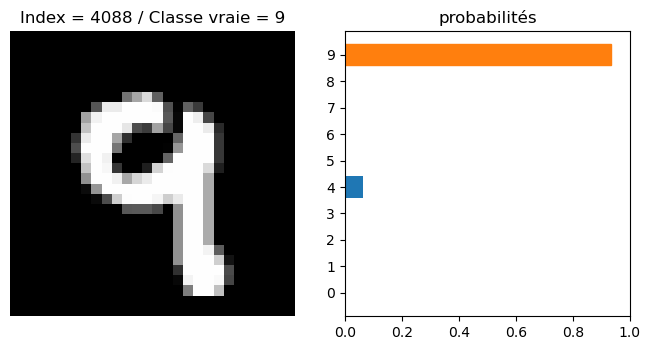

In [91]:
visualiser_image_classification(images_test, labels_test, y_score, index=None)

Vous pouvez vérifier les quelques images suivantes 628, 9925, 4783, 8318 en passant l'argument `index = 628` à la fonction `visualiser_image_classfication` par exemple.

Avec ce réglage de composantes principales, on peut aussi visualiser les reconstructions et les erreurs de reconstruction:

In [92]:
valeurs_propres = pca.explained_variance_
vecteurs_propres = pca.components_.T  # sklearn stocke les vecteurs propres en ligne, donc on transpose

Normalement, on peut compresser et décompresser directement avec l'object `pca`:

```python
image_compressee = pca.transform(image)
image_reconstuite = pca.inverse_transform(image_compressee)
```

Mais ici on a peu triché pour sortir l'ACP de la pipeline pour gagner du temps. On peut facilement réimplémenter les opérations à la main. Pour rappel on calcul les scores (la compression) comme ceci:

$$
    Z = X U^*
$$

et la reconstruction:

$$
    \hat{X} = Z U^{*T}
$$

et enfin, l'erreur:

$$
    \text{Erreur} = X - \hat{X}
$$

Avec $U^*$ la matrice des $k$ premiers vecteurs propres.

On n'oubliera pas d'appliquer également l'opération inverse du recentrage des images :)

In [93]:
k = 16  # prendre ici une valeur cohérente à celle de votre algorithme: select = SelectKComponents(k)
images_test_compressees = images_test_centrees @ vecteurs_propres[:,:k]  # Z = X @ U*
images_test_reconstruites = images_test_compressees @ vecteurs_propres[:,:k].T  + images_mean # X_hat = Z @ U*.T + moyenne
erreurs = images_test - images_test_reconstruites

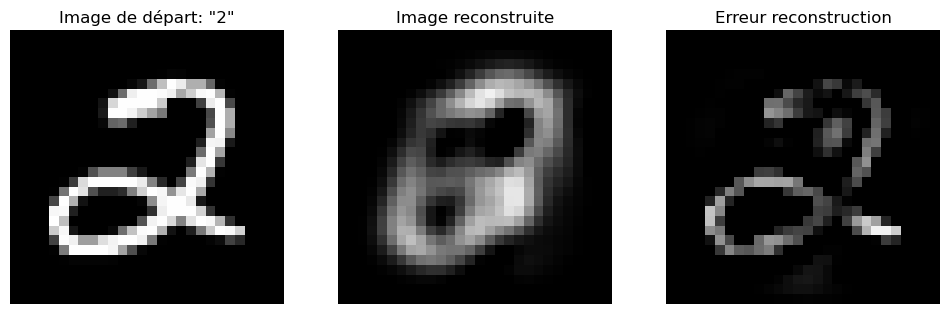

In [94]:
visualiser_acp(images_test, labels_test, images_test_reconstruites, erreurs, index=None)